In [1]:
import os

In [2]:
import warnings
warnings.filterwarnings('ignore')
# Get all the paths
dataset_dir = r'C:\Users\Devar\Desktop\Lung Cancer Detection\Dataset'
dataset_dir = r'C:\Users\Devar\Desktop\Lung Cancer Detection\Dataset'

if not os.path.isdir(dataset_dir):
    alternative_dir = (
        r'C:\Users\Devar\Desktop\Lung Cancer Detection\Dataset'
        r'C:\Users\Devar\Desktop\Lung Cancer Detection\Dataset'
    )

    if os.path.isdir(alternative_dir):
        dataset_dir = alternative_dir
    else:
        raise FileNotFoundError(
            f"Dataset directory not found: {dataset_dir}"
        )

data_dir_list = os.listdir(dataset_dir)
print(data_dir_list)
path, dirs, files = next(os.walk(dataset_dir))
file_count = len(files)
#print(file_count)

['Augmentation Details.txt', 'Benign cases', 'Malignant cases', 'Normal cases', 'Split_data_CNN_0', 'Split_data_inception_V3_1', 'Split_data_vgg16_o', 'train', 'validation']


In [3]:

# Make new base directory
original_dataset_dir = r'C:\Users\Devar\Desktop\Lung Cancer Detection\Dataset'
base_dir = r'C:\Users\Devar\Desktop\Lung Cancer Detection\Dataset\Split_data_CNN_0'
os.makedirs(base_dir, exist_ok=True)

In [4]:
#create two folders (train and validation)
train_dir = os.path.join(base_dir, 'train')
os.makedirs(train_dir, exist_ok=True)

validation_dir = os.path.join(base_dir, 'validation')
os.makedirs(validation_dir, exist_ok=True)

In [5]:
#Under train folder create two folders

train_cloud_dir = os.path.join(train_dir, 'Benign cases')
os.makedirs(train_cloud_dir, exist_ok=True)

train_foggy_dir = os.path.join(train_dir, 'Malignant cases')
os.makedirs(train_foggy_dir, exist_ok=True)

In [6]:
import os
import random
from shutil import copyfile

In [7]:
def split_data(SOURCE, TRAINING, VALIDATION, SPLIT_SIZE):
    files = []
    for filename in os.listdir(SOURCE):
        file = SOURCE + filename
        if os.path.getsize(file) > 0:
            files.append(filename)
        else:
            print(filename + " is zero length, so ignoring.")

    training_length = int(len(files) * SPLIT_SIZE)
    valid_length = int(len(files) - training_length)
    shuffled_set = random.sample(files, len(files))
    training_set = shuffled_set[0:training_length]
    valid_set = shuffled_set[training_length:]

    for filename in training_set:
        this_file = SOURCE + filename
        destination = TRAINING + filename
        copyfile(this_file, destination)

    for filename in valid_set:
        this_file = SOURCE + filename
        destination = VALIDATION + filename
        copyfile(this_file, destination)

In [8]:
BENGIN_SOURCE_DIR = os.path.join(original_dataset_dir, 'Benign cases') + os.sep
TRAINING_BENGIN_DIR = os.path.join(base_dir, 'train', 'Benign cases') + os.sep
VALID_BENGIN_DIR = os.path.join(base_dir, 'validation', 'Benign cases') + os.sep

MALIGNANT_SOURCE_DIR = os.path.join(original_dataset_dir, 'Malignant cases') + os.sep
TRAINING_MALIGNANT_DIR = os.path.join(base_dir, 'train', 'Malignant cases') + os.sep
VALID_MALIGNANT_DIR = os.path.join(base_dir, 'validation', 'Malignant cases') + os.sep

In [9]:
from pathlib import Path

split_size = 0.80

os.makedirs(TRAINING_BENGIN_DIR, exist_ok=True)
os.makedirs(VALID_BENGIN_DIR, exist_ok=True)
os.makedirs(TRAINING_MALIGNANT_DIR, exist_ok=True)
os.makedirs(VALID_MALIGNANT_DIR, exist_ok=True)

dataset_root = Path(original_dataset_dir)
excluded_dir = Path(base_dir).resolve()

def find_class_folder(names):
    for folder in dataset_root.rglob("*"):
        if (
            folder.is_dir()
            and folder.resolve() != excluded_dir
            and folder.name.casefold().replace(" ", "").replace("_", "")
            in names
        ):
            return folder
    return None

benign_source = find_class_folder({"benigncases", "bengincases"})
malignant_source = find_class_folder({"malignantcases"})

if benign_source is not None and malignant_source is not None:
    split_data(
        str(benign_source) + os.sep,
        TRAINING_BENGIN_DIR,
        VALID_BENGIN_DIR,
        split_size
    )
    split_data(
        str(malignant_source) + os.sep,
        TRAINING_MALIGNANT_DIR,
        VALID_MALIGNANT_DIR,
        split_size
    )
else:
    existing_split = all(
        any(Path(folder).iterdir())
        for folder in (
            TRAINING_BENGIN_DIR,
            VALID_BENGIN_DIR,
            TRAINING_MALIGNANT_DIR,
            VALID_MALIGNANT_DIR
        )
    )

    if existing_split:
        print("Source folders were not found; using the existing Split_data_CNN folders.")
    else:
        raise FileNotFoundError(
            f"Original class folders were not found below:\n{original_dataset_dir}\n"
            "Add 'Benign cases'/'Bengin cases' and 'Malignant cases' folders, "
            "or populate Split_data_CNN first."
        )

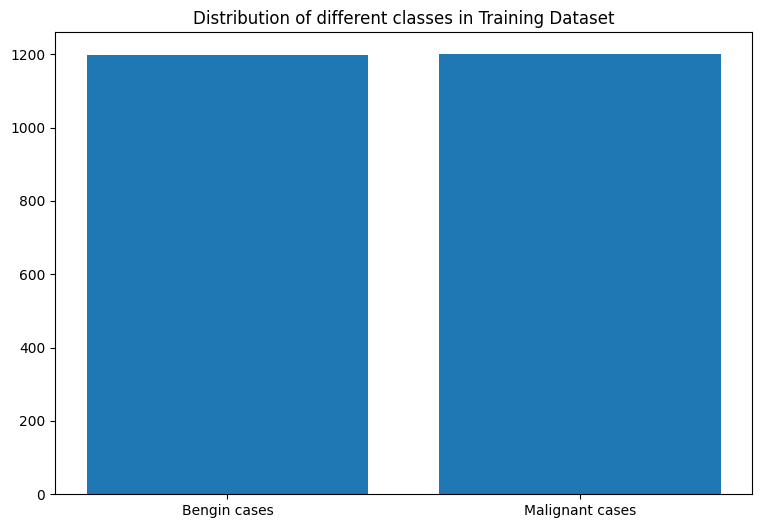

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.image import imread
import pathlib

image_folder = ['Bengin cases', 'Malignant cases']
nimgs = {}
for i in image_folder:
    folder_name = 'Benign cases' if i == 'Bengin cases' else i
    nimages = len(os.listdir(os.path.join(train_dir, folder_name)))
    nimgs[i]=nimages
plt.figure(figsize=(9, 6))
plt.bar(range(len(nimgs)), list(nimgs.values()), align='center')
plt.xticks(range(len(nimgs)), list(nimgs.keys()))
plt.title('Distribution of different classes in Training Dataset')
plt.show()

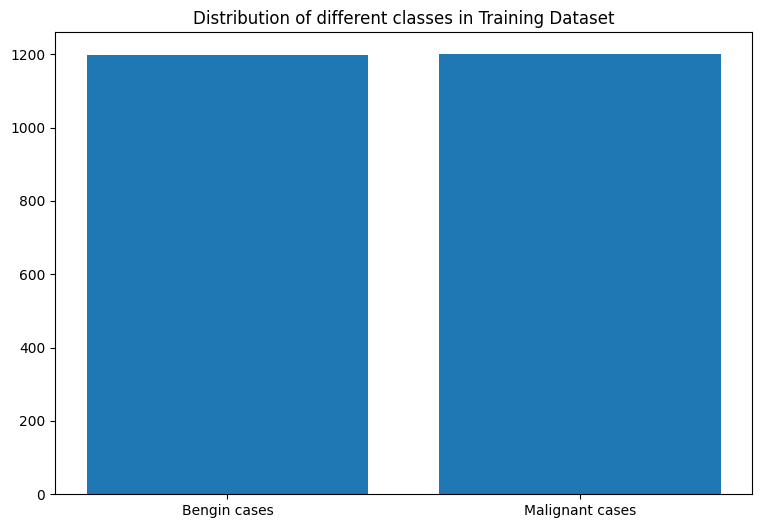

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.image import imread
import pathlib

image_folder = ['Bengin cases', 'Malignant cases']
nimgs = {}
for i in image_folder:
    folder_name = 'Benign cases' if i == 'Bengin cases' else i
    nimages = len(os.listdir(os.path.join(train_dir, folder_name)))
    nimgs[i]=nimages
plt.figure(figsize=(9, 6))
plt.bar(range(len(nimgs)), list(nimgs.values()), align='center')
plt.xticks(range(len(nimgs)), list(nimgs.keys()))
plt.title('Distribution of different classes in Training Dataset')
plt.show()

In [12]:
for i in ['Bengin cases', 'Malignant cases']:
    folder_name = 'Benign cases' if i == 'Bengin cases' else i
    training_path = os.path.join(train_dir, folder_name)
    image_count = len(os.listdir(training_path))
    print(f"Training {i} images are: {image_count}")

Training Bengin cases images are: 1199
Training Malignant cases images are: 1200


In [13]:
validation_folders = {
    'Bengin cases': VALID_BENGIN_DIR,
    'Malignant cases': VALID_MALIGNANT_DIR
}

for class_name, folder_path in validation_folders.items():
    print(
        f"Testing {class_name} images are: "
        f"{len(os.listdir(folder_path))}"
    )

Testing Bengin cases images are: 810
Testing Malignant cases images are: 813


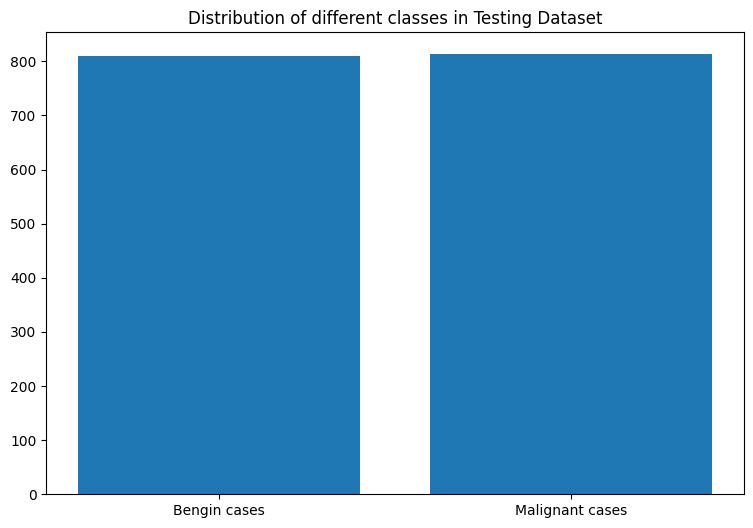

In [14]:
image_folder = ['Bengin cases', 'Malignant cases']
nimgs = {}

for i in image_folder:
    folder_name = 'Benign cases' if i == 'Bengin cases' else i
    validation_path = os.path.join(validation_dir, folder_name)
    nimgs[i] = len(os.listdir(validation_path))

plt.figure(figsize=(9, 6))
plt.bar(range(len(nimgs)), list(nimgs.values()), align='center')
plt.xticks(range(len(nimgs)), list(nimgs.keys()))
plt.title('Distribution of different classes in Testing Dataset')
plt.show()

In [15]:
!pip install tensorflow==2.20.0


[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [16]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from keras.layers import Convolution2D
from keras.layers import MaxPooling2D
from keras.layers import Dropout
from keras.layers import Flatten

In [17]:
import matplotlib.pyplot as plt
import numpy as np
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.preprocessing.image import ImageDataGenerator, array_to_img, img_to_array, load_img

In [18]:
train_datagen = ImageDataGenerator(rescale=1./255,
                                   rotation_range=8,
                                   zoom_range=0.15,
                                   width_shift_range=0.15,
                                   height_shift_range=0.15,
                                   shear_range=0.10,
                                   horizontal_flip=True,
                                   brightness_range=[0.8,1.2],
                                   channel_shift_range=0.15,
                                   fill_mode="nearest")

In [19]:
test_datagen = ImageDataGenerator(rescale=1./255)

In [20]:
x_train = train_datagen.flow_from_directory(
	train_dir,
	target_size=(224, 224),
	batch_size=32,
	class_mode='binary',
	classes=['Benign cases', 'Malignant cases']
)

x_test = test_datagen.flow_from_directory(
	validation_dir,
	target_size=(224, 224),
	batch_size=32,
	class_mode='binary',
	shuffle=False,
	classes=['Benign cases', 'Malignant cases']
)

print(x_train.class_indices)
print(x_test.class_indices)

Found 2399 images belonging to 2 classes.
Found 1623 images belonging to 2 classes.
{'Benign cases': 0, 'Malignant cases': 1}
{'Benign cases': 0, 'Malignant cases': 1}


In [21]:
from tensorflow.keras.layers import Convolution2DTranspose
from tensorflow.keras.models import Sequential
from IPython.core import history
from tensorflow.keras import metrics

In [22]:

model = Sequential()
model.add(Convolution2D (32,(3,3),input_shape=(224,224,3),activation='relu'))
model.add(MaxPooling2D (pool_size=(3,3)))
model.add(Dropout(0.25))
model.add(Convolution2D(64,(3,3),activation='relu'))
model.add(Convolution2D(64,(3,3),activation='relu'))


model.add(MaxPooling2D (pool_size=(2,2)))
model.add(Dropout(0.25))
model.add(Convolution2D(128,(3,3),activation='relu'))
model.add(Convolution2D(128,(3,3),activation='relu'))
model.add(MaxPooling2D (pool_size=(2,2)))
model.add(Dropout(0.25))


model.add(Flatten())
model.add(Dense(units=512,activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(units=128,activation='relu'))
model.add(Dense(1,activation="sigmoid"))

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 70, 70, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 35, 35, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 35, 35, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 33, 33, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 31, 31, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 15, 15, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 15, 15, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 28800)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │    14,746,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,089,665 (57.56 MB)

 Trainable params: 15,089,665 (57.56 MB)

 Non-trainable params: 0 (0.00 B)

In [23]:
model.compile(loss="binary_crossentropy",optimizer='adam',metrics=['accuracy'])

In [24]:
TRAIN_COUNT =len(x_train.filepaths)
TEST_COUNT=len(x_test.filepaths)
TRAIN_STEPS_PER_EPOCH= round(TRAIN_COUNT/32)
VAL_STEPS_PER_EPOCH = round(TEST_COUNT/32)

In [25]:
print(f"TRAIN_STEPS_PER_EPOCH:{TRAIN_STEPS_PER_EPOCH}")
print(f"VAL_STEPS_PER_EPOCH:{VAL_STEPS_PER_EPOCH}")

TRAIN_STEPS_PER_EPOCH:75
VAL_STEPS_PER_EPOCH:51


In [26]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
EARLY_STOP_PATIENCE =5

In [31]:
%pip install tensorflow

import os

# Reduce CPU/MKL memory usage. Restart the kernel before running this cell.
os.environ["TF_ENABLE_ONEDNN_OPTS"] = "0"
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["TF_NUM_INTRAOP_THREADS"] = "1"
os.environ["TF_NUM_INTEROP_THREADS"] = "1"

import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

try:
    tf.config.threading.set_intra_op_parallelism_threads(1)
    tf.config.threading.set_inter_op_parallelism_threads(1)
except RuntimeError:
    pass

split_data_dir = r"C:\Users\Devar\Desktop\Lung Cancer Detection\Dataset\Split_data_CNN_0"

if "train_dir" not in globals() or not os.path.isdir(train_dir):
    train_dir = os.path.join(split_data_dir, "train")

if "validation_dir" not in globals() or not os.path.isdir(validation_dir):
    validation_dir = os.path.join(split_data_dir, "validation")

ImageDataGenerator = tf.keras.preprocessing.image.ImageDataGenerator

train_datagen = ImageDataGenerator(
    rescale=1.0 / 255,
    rotation_range=8
)

test_datagen = ImageDataGenerator(
    rescale=1.0 / 255
)

x_train = train_datagen.flow_from_directory(
    train_dir,
    target_size=(224, 224),
    batch_size=8,
    class_mode="binary"
)

x_test = test_datagen.flow_from_directory(
    validation_dir,
    target_size=(224, 224),
    batch_size=8,
    class_mode="binary",
    shuffle=False
)

TRAIN_STEPS_PER_EPOCH = max(1, (x_train.samples + x_train.batch_size - 1) // x_train.batch_size)
VAL_STEPS_PER_EPOCH = max(1, (x_test.samples + x_test.batch_size - 1) // x_test.batch_size)

tf.keras.backend.clear_session()

base_model = tf.keras.applications.VGG16(
    input_shape=(224, 224, 3),
    include_top=False,
    weights="imagenet"
)

for layer in base_model.layers:
    layer.trainable = False

x = tf.keras.layers.GlobalAveragePooling2D()(base_model.output)
x = tf.keras.layers.Dense(256, activation='relu')(x)
x = tf.keras.layers.Dropout(0.5)(x)
x = tf.keras.layers.Dense(1, activation='sigmoid')(x)

model = tf.keras.models.Model(base_model.input, x)
model.compile(
    loss="binary_crossentropy",
    optimizer="adam",
    metrics=["accuracy"]
)

EARLY_STOP_PATIENCE = 5

# Threading is configured before model creation to reduce CPU/MKL memory usage.

TRAIN_STEPS_PER_EPOCH = max(1, (x_train.samples + x_train.batch_size - 1) // x_train.batch_size)
VAL_STEPS_PER_EPOCH = max(1, (x_test.samples + x_test.batch_size - 1) // x_test.batch_size)
# Fix the MKL/CPU memory issue that can happen with VGG16 on Windows
try:
    tf.config.threading.set_intra_op_parallelism_threads(1)
    tf.config.threading.set_inter_op_parallelism_threads(1)
except RuntimeError:
    pass

# Lower the batch size to reduce memory pressure during training
x_train.batch_size = 4
x_test.batch_size = 4

TRAIN_STEPS_PER_EPOCH = max(1, (x_train.samples + x_train.batch_size - 1) // x_train.batch_size)
VAL_STEPS_PER_EPOCH = max(1, (x_test.samples + x_test.batch_size - 1) // x_test.batch_size)

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=EARLY_STOP_PATIENCE,
    restore_best_weights=True
)

checkpoint = ModelCheckpoint(
    filepath="best_model.keras",
    monitor="val_loss",
    save_best_only=True,
    mode="min",
    verbose=1
)

callbacks_list = [early_stop, checkpoint]

history = model.fit(
    x_train,
    steps_per_epoch=TRAIN_STEPS_PER_EPOCH,
    epochs=20,
    validation_data=x_test,
    validation_steps=VAL_STEPS_PER_EPOCH,
    callbacks=callbacks_list
)

Note: you may need to restart the kernel to use updated packages.
Found 2399 images belonging to 2 classes.



[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Found 1623 images belonging to 2 classes.
Epoch 1/20
600/600 ━━━━━━━━━━━━━━━━━━━━ 0s 887ms/step - accuracy: 0.7878 - loss: 0.4586
Epoch 1: val_loss improved from None to 0.23056, saving model to best_model.keras

Epoch 1: finished saving model to best_model.keras
600/600 ━━━━━━━━━━━━━━━━━━━━ 3123s 5s/step - accuracy: 0.7878 - loss: 0.4586 - val_accuracy: 0.9359 - val_loss: 0.2306
Epoch 2/20
600/600 ━━━━━━━━━━━━━━━━━━━━ 0s 899ms/step - accuracy: 0.9191 - loss: 0.2207
Epoch 2: val_loss improved from 0.23056 to 0.22024, saving model to best_model.keras

Epoch 2: finished saving model to best_model.keras
600/600 ━━━━━━━━━━━━━━━━━━━━ 968s 2s/step - accuracy: 0.9191 - loss: 0.2207 - val_accuracy: 0.9094 - val_loss: 0.2202
Epoch 3/20
600/600 ━━━━━━━━━━━━━━━━━━━━ 0s 901ms/step - accuracy: 0.9421 - loss: 0.1553
Epoch 3: val_loss improved from 0.22024 to 0.10264, saving model to best_model.keras

Epoch 3: finished saving model to best_model.keras
600/600 ━━━━━━━━━━━━━━━━━━━━ 947s 2s/step - accur

AbortedError: Graph execution error:

Detected at node StatefulPartitionedCall/functional_1/block4_conv2_1/Relu defined at (most recent call last):
<stack traces unavailable>
Operation received an exception:Status: 1, message: could not create a memory object, in file tensorflow/core/kernels/mkl/mkl_conv_ops.cc:1112
	 [[{{node StatefulPartitionedCall/functional_1/block4_conv2_1/Relu}}]] [Op:__inference_multi_step_on_iterator_3860]